In [1]:
from riboss.orfs import translate

In [4]:
na = 'atggtcgggtag'

In [5]:
translate(na)

'MVG'

In [ ]:
import os
import pandas as pd
from riboss.wrapper import transcriptome_assembly 

In [1]:
! ls -lh ../ref/Araport11_GTF_genes_transposons.Oct2023.gtf.gz

-rwxrwxr-x+ 1 phaan839 4294967294 6.4M Dec 18 10:03 ../ref/Araport11_GTF_genes_transposons.Oct2023.gtf.gz


In [12]:
! gtfToGenePred -genePredExt -ignoreGroupsWithoutExons ../ref/Araport11_GTF_genes_transposons.current.gtf.gz stdout \
| genePredToBed stdin ../ref/Araport11_GTF_genes_transposons.current.bed
    


In [16]:
! zcat ../ref/Araport11_GTF_genes_transposons.current.gtf.gz \
| grep -i 'uorf' \
| sed 's/uORF/exon/' \
| gtfToGenePred -genePredExt -ignoreGroupsWithoutExons stdin ../ref/Araport11_GTF_genes_transposons.current.uORFs.bed


In [4]:
# clean of above 6MB OCT 7th 2024

! wget https://www.arabidopsis.org/api/download-files/download?filePath=Genes/Araport11_genome_release/Araport11_GTF_genes_transposons.current.gtf.gz \
-O Araport11_GTF_genes_transposons.current.gtf.gz

!wget https://www.arabidopsis.org/download/file?path=Genes/TAIR10_genome_release/TAIR10_chromosome_files/TAIR10_chr_all.fas.gz -O \
../ref/TAIR10_chr_all.fas.gz
! gunzip ..ref/TAIR_10_chr_all.fas.gz

! gtfToGenePred -genePredExt -ignoreGroupsWithoutExons ../ref/Araport11_GTF_genes_transposons.current.gtf.gz stdout \
| genePredToBed stdin ../ref/Araport11_GTF_genes_transposons.current.bed

! zcat ../ref/Araport11_GTF_genes_transposons.current.gtf.gz \
| grep -i 'uorf' | sed 's/uORF/exon/' \
| gtfToGenePred -genePredExt -ignoreGroupsWithoutExons stdin ../ref/Araport11_GTF_genes_transposons.current.uorfs.gp

--2025-01-13 10:42:52--  https://www.arabidopsis.org/api/download-files/download?filePath=Genes/Araport11_genome_release/Araport11_GTF_genes_transposons.current.gtf.gz
Resolving www.arabidopsis.org (www.arabidopsis.org)... 15.197.242.219, 76.223.67.159
Connecting to www.arabidopsis.org (www.arabidopsis.org)|15.197.242.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [binary/octet-stream]
Saving to: ‘Araport11_GTF_genes_transposons.current.gtf.gz’

Araport11_GTF_genes     [    <=>             ]   6.34M  6.12MB/s    in 1.0s    

2025-01-13 10:42:54 (6.12 MB/s) - ‘Araport11_GTF_genes_transposons.current.gtf.gz’ saved [6644560]

--2025-01-13 10:42:54--  https://www.arabidopsis.org/download/file?path=Genes/TAIR10_genome_release/TAIR10_chromosome_files/TAIR10_chr_all.fas.gz
Resolving www.arabidopsis.org (www.arabidopsis.org)... 15.197.242.219, 76.223.67.159
Connecting to www.arabidopsis.org (www.arabidopsis.org)|15.197.242.219|:443... connected.
HTTP 

In [6]:
! gunzip ..ref/TAIR10_chr_all.fas.gz


gzip: ..ref/TAIR_10_chr_all.fas.gz: No such file or directory


In [17]:
! head ../ref/Araport11_GTF_genes_transposons.current.bed


Chr1	3630	5899	AT1G01010.1	0	+	3759	5630	0	6	283,281,120,390,153,461,	0,365,855,1075,1543,1808,
Chr1	6787	9130	AT1G01020.1	0	-	6914	8666	0	9	282,76,67,86,74,46,90,48,560,	0,369,596,776,974,1154,1448,1629,1783,
Chr1	6787	8737	AT1G01020.2	0	-	7314	8666	0	8	282,294,86,74,46,90,48,167,	0,369,776,974,1154,1448,1629,1783,
Chr1	6787	9130	AT1G01020.3	0	-	6914	8442	0	8	282,76,67,86,74,46,229,560,	0,369,596,776,974,1154,1448,1783,
Chr1	6787	9130	AT1G01020.4	0	-	6914	8442	0	8	282,76,67,86,74,46,229,537,	0,369,596,776,974,1154,1448,1806,
Chr1	6787	9130	AT1G01020.5	0	-	6914	8419	0	9	282,76,67,86,74,46,90,48,537,	0,369,596,776,974,1154,1448,1629,1806,
Chr1	6787	8737	AT1G01020.6	0	-	7314	8419	0	6	282,294,86,90,48,144,	0,369,776,1448,1629,1806,
Chr1	11648	13714	AT1G01030.1	0	-	11863	12940	0	2	1525,380,	0,1686,
Chr1	11648	13714	AT1G01030.2	0	-	11863	12940	0	3	706,750,380,	0,775,1686,
Chr1	23120	31227	AT1G01040.1	0	+	23518	31079	0	20	1331,114,211,395,220,173,123,161,234,151,183,162,96,629,98,191,906,165

In [18]:
! awk '$7==$8' ../ref/Araport11_GTF_genes_transposons.current.bed | wc -l

9967


In [20]:
! awk '$7!=$8' ../ref/Araport11_GTF_genes_transposons.current.bed | wc -l

48270


In [23]:
! zcat ../ref/TAIR10_chr_all.fas.gz | head

>Chr1 CHROMOSOME dumped from ADB: Feb/3/09 16:9; last updated: 2009-02-02
CCCTAAACCCTAAACCCTAAACCCTAAACCTCTGAATCCTTAATCCCTAAATCCCTAAATCTTTAAATCCTACATCCAT
GAATCCCTAAATACCTAATTCCCTAAACCCGAAACCGGTTTCTCTGGTTGAAAATCATTGTGTATATAATGATAATTTT
ATCGTTTTTATGTAATTGCTTATTGTTGTGTGTAGATTTTTTAAAAATATCATTTGAGGTCAATACAAATCCTATTTCT
TGTGGTTTTCTTTCCTTCACTTAGCTATGGATGGTTTATCTTCATTTGTTATATTGGATACAAGCTTTGCTACGATCTA
CATTTGGGAATGTGAGTCTCTTATTGTAACCTTAGGGTTGGTTTATCTCAAGAATCTTATTAATTGTTTGGACTGTTTA
TGTTTGGACATTTATTGTCATTCTTACTCCTTTGTGGAAATGTTTGTTCTATCAATTTATCTTTTGTGGGAAAATTATT
TAGTTGTAGGGATGAAGTCTTTCTTCGTTGTTGTTACGCTTGTCATCTCATCTCTCAATGATATGGGATGGTCCTTTAG
CATTTATTCTGAAGTTCTTCTGCTTGATGATTTTATCCTTAGCCAAAAGGATTGGTGGTTTGAAGACACATCATATCAA
AAAAGCTATCGCCTCGACGATGCTCTATTTCTATCCTTGTAGCACACATTTTGGCACTCAAAAAAGTATTTTTAGATGT

gzip: stdout: Broken pipe


In [21]:
! wc -l ../ref/Araport11_GTF_genes_transposons.current.pc.bed


48270 ../ref/Araport11_GTF_genes_transposons.current.pc.bed


In [24]:
! bedtools getfasta -bed ../ref/Araport11_GTF_genes_transposons.current.bed -fi ../ref/TAIR10_chr_all.fas -name | head

>AT1G01010.1::Chr1:3630-5899
AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGAGAAATACAGATTACAGAGAGCGAGAGAGATCGACGGCGAAGCTCTTTACCCGGAAACCATTGAAATCGGACGGTTTAGTGAAAATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACAAAATCGAAGGAAACACTAGCCGCGACGTTGAAGTAGCCATCAGCGAGGTCAACATCTGTAGCTACGATCCTTGGAACTTGCGCTGTAAGTTCCGAATTTTCTGAATTTCATTTGCAAGTAATCGATTTAGGTTTTTGATTTTAGGGTTTTTTTTTGTTTTGAACAGTCCAGTCAAAGTACAAATCGAGAGATGCTATGTGGTACTTCTTCTCTCGTAGAGAAAACAACAAAGGGAATCGACAGAGCAGGACAACGGTTTCTGGTAAATGGAAGCTTACCGGAGAATCTGTTGAGGTCAAGGACCAGTGGGGATTTTGTAGTGAGGGCTTTCGTGGTAAGATTGGTCATAAAAGGGTTTTGGTGTTCCTCGATGGAAGATACCCTGACAAAACCAAATCTGATTGGGTTATCCACGAGTTCCACTACGACCTCTTACCAGAACATCAGGTTTTCTTCTATTCATATATATATATATATATATATGTGGATATATATATATGTGGTTTCTGCTGATTCATAGTTAGAATTTGAGTTATGCAAATTAGAAACTATGTAATGTAACTCTATTTAGGTTCAGCAGCTATTTTAGGCTTAGCTTACTCTCACCAATGTTTTATACTGATGAACTTATGTGCTTACCTCCGGAAATTTTACAGAGGACATATGTCATCTGCAGACTTGAGTACAAGGGTGATGATGCGGACATTCTATCTGCTTATGCAATAGATCCCACTCCCGCTTTTGTCCCCAATATGACTAGTAGTGCAGGTTC

In [7]:
! bedtools getfasta -bed ../ref/Araport11_GTF_genes_transposons.current.pc.bed -fi ../ref/TAIR10_chr_all.fas \
-s -split -name -fo ../ref/Araport11_GTF_genes_transposons.current.pc.fa

In [27]:
! grep -c ">" ../ref/Araport11_GTF_genes_transposons.current.pc.fa

48270


In [10]:
! head ../ref/Araport11_GTF_genes_transposons.current.pc.bed

Chr1	3630	5899	AT1G01010.1	0	+	3759	5630	0	6	283,281,120,390,153,461,	0,365,855,1075,1543,1808,
Chr1	6787	9130	AT1G01020.1	0	-	6914	8666	0	9	282,76,67,86,74,46,90,48,560,	0,369,596,776,974,1154,1448,1629,1783,
Chr1	6787	8737	AT1G01020.2	0	-	7314	8666	0	8	282,294,86,74,46,90,48,167,	0,369,776,974,1154,1448,1629,1783,
Chr1	6787	9130	AT1G01020.3	0	-	6914	8442	0	8	282,76,67,86,74,46,229,560,	0,369,596,776,974,1154,1448,1783,
Chr1	6787	9130	AT1G01020.4	0	-	6914	8442	0	8	282,76,67,86,74,46,229,537,	0,369,596,776,974,1154,1448,1806,
Chr1	6787	9130	AT1G01020.5	0	-	6914	8419	0	9	282,76,67,86,74,46,90,48,537,	0,369,596,776,974,1154,1448,1629,1806,
Chr1	6787	8737	AT1G01020.6	0	-	7314	8419	0	6	282,294,86,90,48,144,	0,369,776,1448,1629,1806,
Chr1	11648	13714	AT1G01030.1	0	-	11863	12940	0	2	1525,380,	0,1686,
Chr1	11648	13714	AT1G01030.2	0	-	11863	12940	0	3	706,750,380,	0,775,1686,
Chr1	23120	31227	AT1G01040.1	0	+	23518	31079	0	20	1331,114,211,395,220,173,123,161,234,151,183,162,96,629,98,191,906,165

In [1]:
! pwd


/projects/health_sciences/bms/biochemistry/lim_group/riboss_manuscript/jupyter_notebooks


In [8]:
! head ../ref/Araport11_GTF_genes_transposons.current.pc.fa

>AT1G01010.1::Chr1:3630-5899(+)
AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGAGAAATACAGATTACAGAGAGCGAGAGAGATCGACGGCGAAGCTCTTTACCCGGAAACCATTGAAATCGGACGGTTTAGTGAAAATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACAAAATCGAAGGAAACACTAGCCGCGACGTTGAAGTAGCCATCAGCGAGGTCAACATCTGTAGCTACGATCCTTGGAACTTGCGCTTCCAGTCAAAGTACAAATCGAGAGATGCTATGTGGTACTTCTTCTCTCGTAGAGAAAACAACAAAGGGAATCGACAGAGCAGGACAACGGTTTCTGGTAAATGGAAGCTTACCGGAGAATCTGTTGAGGTCAAGGACCAGTGGGGATTTTGTAGTGAGGGCTTTCGTGGTAAGATTGGTCATAAAAGGGTTTTGGTGTTCCTCGATGGAAGATACCCTGACAAAACCAAATCTGATTGGGTTATCCACGAGTTCCACTACGACCTCTTACCAGAACATCAGAGGACATATGTCATCTGCAGACTTGAGTACAAGGGTGATGATGCGGACATTCTATCTGCTTATGCAATAGATCCCACTCCCGCTTTTGTCCCCAATATGACTAGTAGTGCAGGTTCTGTGGTCAACCAATCACGTCAACGAAATTCAGGATCTTACAACACTTACTCTGAGTATGATTCAGCAAATCATGGCCAGCAGTTTAATGAAAACTCTAACATTATGCAGCAGCAACCACTTCAAGGATCATTCAACCCTCTCCTTGAGTATGATTTTGCAAATCACGGCGGTCAGTGGCTGAGTGACTATATCGACCTGCAACAGCAAGTTCCTTACTTGGCACCTTATGAAAATGAGTCGGAGATGATTTGGAAGCATGTGATTGAAGAAAATTTTGAGTTTTTGGT

In [18]:
! awk '{print length ($1)}' ../ref/Araport11_GTF_genes_transposons.current.pc.fa | head -n2

31
1688


In [16]:
! awk '{print $4,$3-$2}' ../ref/Araport11_GTF_genes_transposons.current.pc.bed | head -n1

AT1G01010.1 2269


In [19]:
! echo 283,281,120,390,153,461 | sed 's/,/+/g'

283+281+120+390+153+461


In [20]:
283+281+120+390+153+461

1688

In [2]:
# Build STAR index for the arabidopsis transcriptome
import os
from riboss.wrapper import build_star_index

In [3]:
tx_assembly = '../ref/Araport11_GTF_genes_transposons.current.pc.fa'
index = os.path.split(tx_assembly)[0] + '/' + '.'.join(os.path.split(tx_assembly)[1].split(os.extsep)[:-1])


build_star_index(tx_assembly, index, delim=':')

INFO:root:renamed ../ref/Araport11_GTF_genes_transposons.current.pc.fa as ../ref/Araport11_GTF_genes_transposons.current.pc.original.fasta
INFO:root:cleaned up fasta headers and saved as ../ref/Araport11_GTF_genes_transposons.current.pc.fa


	/home/gibal016/miniforge3/envs/riboss/bin/STAR-avx2 --runMode genomeGenerate --runThreadN 4 --genomeDir ../ref/Araport11_GTF_genes_transposons.current.pc --genomeFastaFiles ../ref/Araport11_GTF_genes_transposons.current.pc.fa --genomeSAindexNbases 7 --genomeChrBinNbits 11
	STAR version: 2.7.11b   compiled: 2024-07-03T14:39:20+0000 :/opt/conda/conda-bld/star_1720017372352/work/source
Jan 13 11:32:51 ..... started STAR run
Jan 13 11:32:51 ... starting to generate Genome files
Jan 13 11:32:53 ... starting to sort Suffix Array. This may take a long time...
Jan 13 11:32:53 ... sorting Suffix Array chunks and saving them to disk...
Jan 13 11:33:17 ... loading chunks from disk, packing SA...
Jan 13 11:33:21 ... finished generating suffix array
Jan 13 11:33:21 ... generating Suffix Array index
Jan 13 11:33:21 ... completed Suffix Array index
Jan 13 11:33:21 ... writing Genome to disk ...
Jan 13 11:33:22 ... writing Suffix Array to disk ...


INFO:root:saved index to ../ref/Araport11_GTF_genes_transposons.current.pc


Jan 13 11:33:23 ... writing SAindex to disk
Jan 13 11:33:23 ..... finished successfully


In [4]:
! head ../ref/Araport11_GTF_genes_transposons.current.pc/chrName.txt

AT1G01010.1
AT1G01020.1
AT1G01020.2
AT1G01020.3
AT1G01020.4
AT1G01020.5
AT1G01020.6
AT1G01030.1
AT1G01030.2
AT1G01040.1


In [1]:
from riboss.orfs import orf_finder
import pyranges as pr
import pandas as pd

annotation='../ref/Araport11_GTF_genes_transposons.current.pc.bed'
fasta='../../riboss_manuscript/ref/TAIR10_chr_all.fas'

cds_range, df = orf_finder(annotation, fasta, ncrna=False, outdir=None, start_codon=["ATG", "ACG", "CTG", "GTG", "TTG"])

finding all ORFs       : 100%|██████████████████████████████| 48.3k/48.3k [01:33<00:00, 516it/s]
converting coordinates : 100%|█████████████████████████████| 3.48M/3.48M [00:11<00:00, 315kit/s]
converting coordinates : 100%|████████████████████████████| 3.51M/3.51M [02:02<00:00, 28.6kit/s]
INFO:root:found 2421284 ORFs in 6 min 58 s
INFO:root:saved sequences as ../ref/Araport11_GTF_genes_transposons.current.pc.transcripts.fa
INFO:root:saved CDS range as ../ref/Araport11_GTF_genes_transposons.current.pc.cds_range.txt


In [6]:
df

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
0,Chr1,AT1G01010.1,+,"[129, 1419]",ATG,129,1419,3759.0,5630.0,mORF,1290
276,Chr1,AT1G01040.1,+,"[398, 6128]",ATG,398,6128,23518.0,31079.0,mORF,5730
420,Chr1,AT1G01040.2,+,"[103, 5836]",ATG,103,5836,23518.0,31079.0,mORF,5733
1309,Chr1,AT1G01110.1,+,"[754, 1849]",ATG,754,1849,53021.0,54494.0,mORF,1095
1329,Chr1,AT1G01110.2,+,"[286, 1870]",ATG,286,1870,52238.0,54494.0,mORF,1584
...,...,...,...,...,...,...,...,...,...,...,...
1807683,ChrM,ATMG00570.1,-,"[839, 842]",ATG,839,842,218904.0,218907.0,dORF,3
1807898,ChrM,ATMG00650.1,-,"[10, 130]",ATG,10,130,361809.0,361929.0,dORF,120
1807899,ChrM,ATMG00650.1,-,"[67, 130]",ATG,67,130,361809.0,361872.0,dORF,63
1807900,ChrM,ATMG00650.1,-,"[113, 215]",ATG,113,215,361724.0,361826.0,dORF,102


In [7]:
df[df.tid=="AT1G01010.1"]

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
0,Chr1,AT1G01010.1,+,"[129, 1419]",ATG,129,1419,3759.0,5630.0,mORF,1290
29,Chr1,AT1G01010.1,+,"[1461, 1521]",ATG,1461,1521,5672.0,5732.0,dORF,60
30,Chr1,AT1G01010.1,+,"[1538, 1544]",ATG,1538,1544,5749.0,5755.0,dORF,6
31,Chr1,AT1G01010.1,+,"[1579, 1687]",ATG,1579,1687,5790.0,5898.0,dORF,108
32,Chr1,AT1G01010.1,+,"[1597, 1687]",ATG,1597,1687,5808.0,5898.0,dORF,90
33,Chr1,AT1G01010.1,+,"[1616, 1622]",ATG,1616,1622,5827.0,5833.0,dORF,6


In [9]:
df[df.tid=="AT4G03260.1"] 	


,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
1137148,Chr4,AT4G03260.1,+,"[646, 2680]",ATG,646,2680,1429091.0,1431431.0,mORF,2034
1137144,Chr4,AT4G03260.1,+,"[3, 27]",ATG,3,27,1428104.0,1428128.0,uORF,24
1137145,Chr4,AT4G03260.1,+,"[45, 132]",ATG,45,132,1428146.0,1428233.0,uORF,87
1137146,Chr4,AT4G03260.1,+,"[616, 622]",ATG,616,622,1429061.0,1429067.0,uORF,6
1137147,Chr4,AT4G03260.1,+,"[626, 728]",ATG,626,728,1429071.0,1429290.0,uORF,102
1137193,Chr4,AT4G03260.1,+,"[2730, 2742]",ATG,2730,2742,1431481.0,1431493.0,dORF,12
1137194,Chr4,AT4G03260.1,+,"[2736, 2742]",ATG,2736,2742,1431487.0,1431493.0,dORF,6
1137195,Chr4,AT4G03260.1,+,"[2843, 2918]",ATG,2843,2918,1431594.0,1431669.0,dORF,75
1137196,Chr4,AT4G03260.1,+,"[2862, 2892]",ATG,2862,2892,1431613.0,1431643.0,dORF,30
1137197,Chr4,AT4G03260.1,+,"[2917, 3031]",ATG,2917,3031,1431668.0,1431782.0,dORF,114


In [10]:
df.value_counts('ORF_type')

ORF_type
dORF    389949
oORF    100733
uORF     77522
mORF     48148
Name: count, dtype: int64

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns 

<Axes: xlabel='ORF_type', ylabel='ORF_length'>

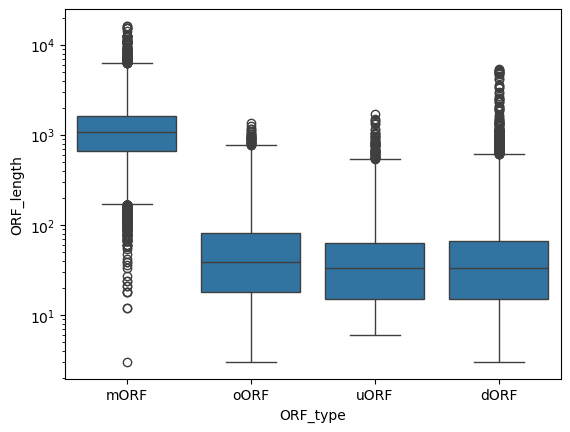

In [18]:
sns.boxplot(data=df, x = 'ORF_type', y='ORF_length',log_scale=True)

In [23]:
df.groupby(['ORF_type'])['ORF_length'].describe()

,count,mean,std,min,25%,50%,75%,max
ORF_type,,,,,,,,
dORF,389949.0,50.976828,64.166802,3.0,15.0,33.0,66.0,5358.0
mORF,48148.0,1299.241692,982.148623,3.0,660.0,1086.0,1629.0,16203.0
oORF,100733.0,60.160791,62.149678,3.0,18.0,39.0,81.0,1341.0
uORF,77522.0,49.239364,53.921785,6.0,15.0,33.0,63.0,1689.0


In [24]:
df.groupby(['ORF_type'])['ORF_length'].agg('median')

ORF_type
dORF      33.0
mORF    1086.0
oORF      39.0
uORF      33.0
Name: ORF_length, dtype: float64

In [15]:
df[df.tid=='AT1G01010.1']

,Chromosome,tid,Strand,ORF_range,start_codon,ORF_start,ORF_end,Start,End,ORF_type,ORF_length
0,Chr1,AT1G01010.1,+,"[129, 1419]",ATG,129,1419,3759.0,5630.0,mORF,1290
29,Chr1,AT1G01010.1,+,"[1461, 1521]",ATG,1461,1521,5672.0,5732.0,dORF,60
30,Chr1,AT1G01010.1,+,"[1538, 1544]",ATG,1538,1544,5749.0,5755.0,dORF,6
31,Chr1,AT1G01010.1,+,"[1579, 1687]",ATG,1579,1687,5790.0,5898.0,dORF,108
32,Chr1,AT1G01010.1,+,"[1597, 1687]",ATG,1597,1687,5808.0,5898.0,dORF,90
33,Chr1,AT1G01010.1,+,"[1616, 1622]",ATG,1616,1622,5827.0,5833.0,dORF,6


In [13]:
df.value_counts(['tid', 'ORF_type']).reset_index()

,tid,ORF_type,count
0,AT1G55860.1,oORF,181
1,AT1G67120.2,dORF,145
2,AT1G67120.1,dORF,144
3,AT2G45540.2,dORF,122
4,AT3G44690.1,dORF,119
...,...,...,...
127306,AT3G54500.1,mORF,1
127307,AT3G54500.1,uORF,1
127308,AT3G54500.2,mORF,1
127309,AT1G16515.1,mORF,1


<Axes: xlabel='ORF_type', ylabel='ORF_length'>

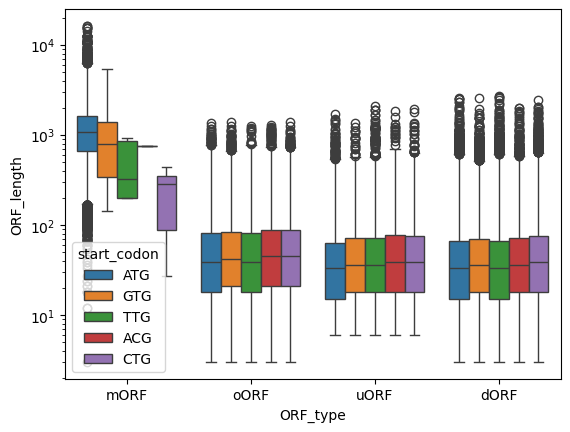

In [4]:
sns.boxplot(data=df, x='ORF_type', y='ORF_length', hue='start_codon', log_scale=True)

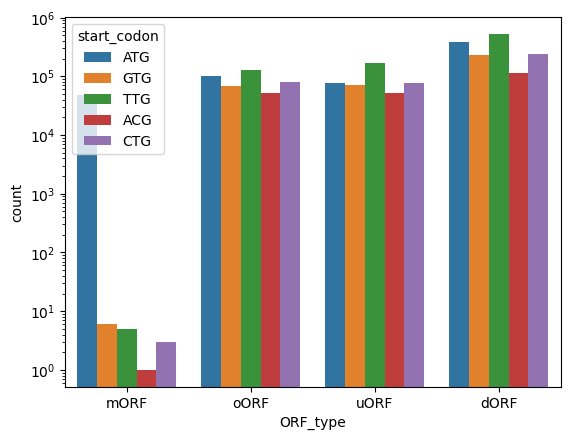

In [13]:
# sns.countplot(data=df[df.ORF_type!='dORF'], x = 'ORF_type', hue= 'start_codon')

sns.countplot(data=df, x = 'ORF_type', hue= 'start_codon')


plt.yscale('log')